# Session 8: Edge Detection

- Ex8_1: Change object's color by Region Setting
- Ex8_2: Edge Detection with Prewitt Operators
- Ex8_3: Edge Detection with Sobel Operators
- Ex8_4: Canny Edge Detector
- Ex8_5: Hough Transform
- Ex8_6: Hough Transform Application - Text Rotation
- Ex8_7: Hough Transform Application - Coin Edge Detection

In [1]:
# load packages
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage.measure import label
from skimage.color import label2rgb
from skimage.filters import threshold_otsu

In [2]:
# Create a link to Session folder
PATH = '/content/drive/MyDrive/IVP/Session_08/'

# Font size for figures
FS = 12

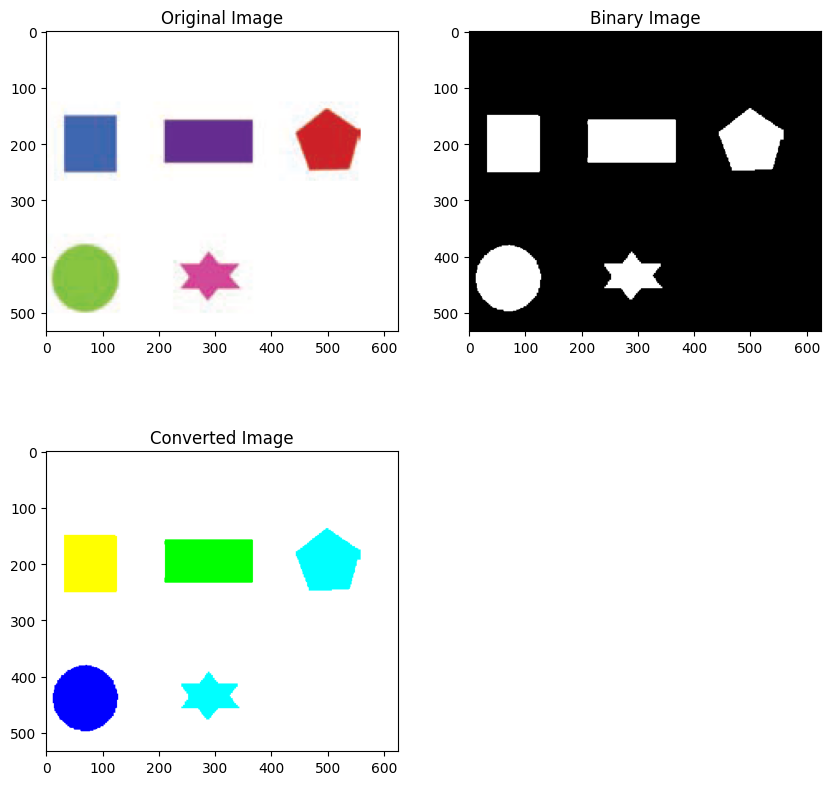

In [3]:
#Ex8_1: Change object's color by Region Setting
Img = cv2.imread(PATH + 'shapes.png')

Img_gray = cv2.cvtColor(Img, cv2.COLOR_BGR2GRAY)

level = threshold_otsu(Img_gray)
Img_bw = (Img_gray < level).astype(np.uint8) * 255
# thres_val, Img_bw = cv2.threshold(Img_gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

# Assign labels to objects
L = label(Img_bw, connectivity=2)

cmap = np.array([
    [0, 255, 255], #pentagon = aqua
    [255, 255, 0], #square = yellow
    [0, 255, 0], #rectangle = lime
    [0, 0, 128], #circle = navy
    [0, 128, 128] #asterisk = teal
])

# Convert labels (objects) to the new color map
Img_converted = label2rgb(L, colors=cmap, bg_label=0,bg_color=(1,1,1), kind='overlay')

# Display Results
plt.figure(figsize=(10,10))
plt.subplot(2,2,1), plt.imshow(cv2.cvtColor(Img, cv2.COLOR_BGR2RGB)), plt.title('Original Image', fontsize=FS)
plt.subplot(2,2,2), plt.imshow(Img_bw, cmap='gray'), plt.title('Binary Image', fontsize=FS)
plt.subplot(2,2,3), plt.imshow(Img_converted), plt.title('Converted Image', fontsize=FS)
plt.show()


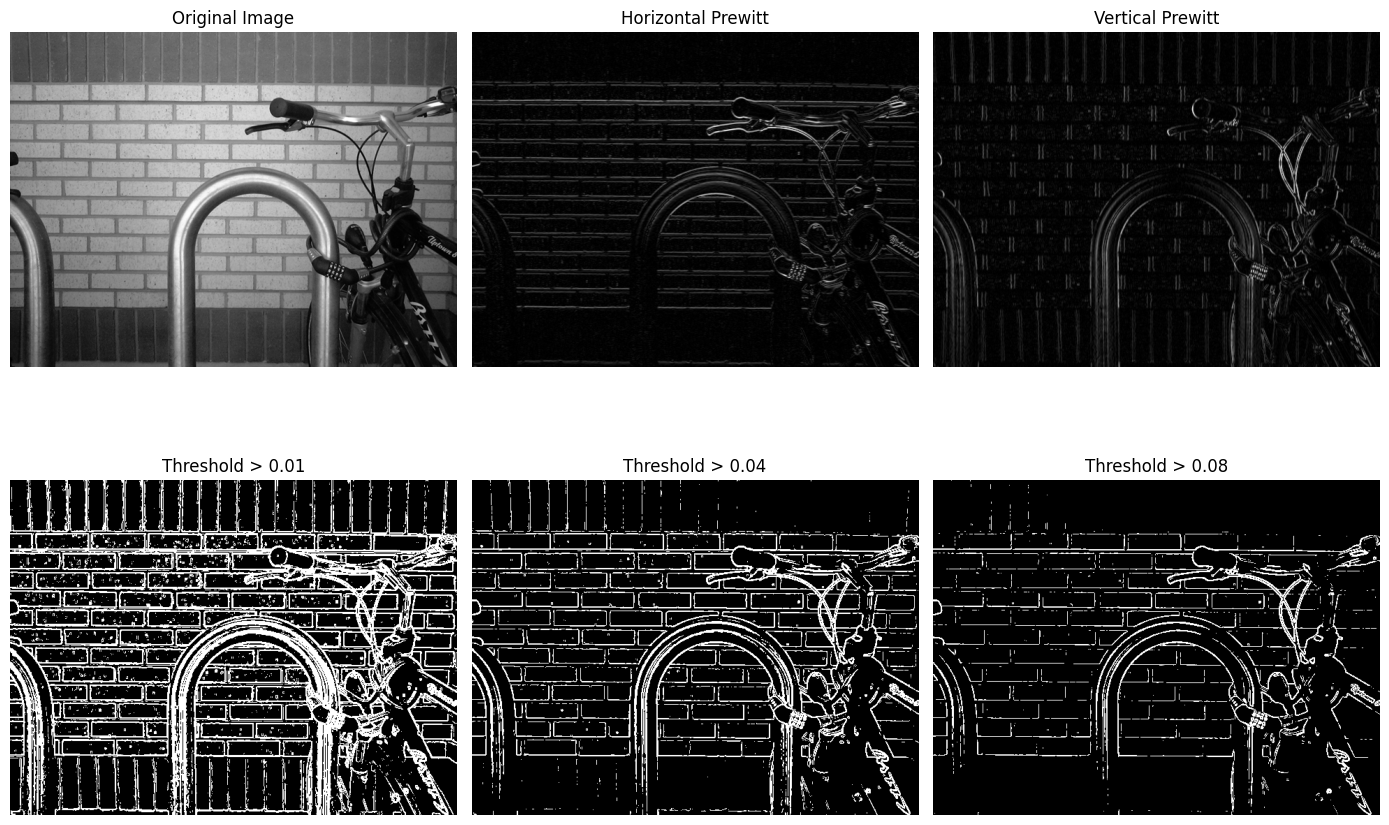

In [4]:
#Ex8_2: Edge Detection with Prewitt Operators
Img = cv2.imread(PATH + 'bike.png', cv2.IMREAD_GRAYSCALE)

# Convert from integer to double format
Img = Img.astype(np.float64)

# Create Prewith operators
ph = np.array([[-1,-1,-1],  # detects horizontal edges
              [0,0,0],
              [1,1,1]])

pv = np.array([[-1,0,1],    # detects vertical edges
              [-1,0,1],
              [-1,0,1]])

# Apply Prewitt in horizontal direction
filtered_Img1 = cv2.filter2D(Img, -1, ph, borderType=cv2.BORDER_REPLICATE)
filtered_Img1 = np.abs(filtered_Img1)
filtered_Img1 = filtered_Img1 / np.max(filtered_Img1)

# Apply Prewitt in vertical direction
filtered_Img2 = cv2.filter2D(Img, -1, pv, borderType=cv2.BORDER_REPLICATE)
filtered_Img2 = np.abs(filtered_Img2)
filtered_Img2 = filtered_Img2 / np.max(filtered_Img2) #normalize the filtered_Img2

# Combine two operators in both directions
# G2^2 = Gx^2 + Gy^2
filtered_Img3 = filtered_Img1 ** 2 + filtered_Img2 ** 2
log_filtered_Img3 = np.log(filtered_Img3 + 1)
log_filtered_Img3 = log_filtered_Img3 / np.max(log_filtered_Img3) #normalize the filtered_Img3

# Get three different thresholds
bw_edge1 = log_filtered_Img3 > 0.01
bw_edge2 = log_filtered_Img3 > 0.04
bw_edge3 = log_filtered_Img3 > 0.08

# Display results
plt.figure(figsize=(14,10))

plt.subplot(2, 3, 1), plt.imshow(Img.astype(np.uint8), cmap='gray'), plt.title('Original Image', fontsize=FS), plt.axis('off')
plt.subplot(2, 3, 2), plt.imshow(filtered_Img1, cmap='gray'), plt.title('Horizontal Prewitt', fontsize=FS), plt.axis('off')
plt.subplot(2, 3, 3), plt.imshow(filtered_Img2, cmap='gray'), plt.title('Vertical Prewitt', fontsize=FS), plt.axis('off')
plt.subplot(2, 3, 4), plt.imshow(bw_edge1, cmap='gray'), plt.title('Threshold > 0.01', fontsize=FS), plt.axis('off')
plt.subplot(2, 3, 5), plt.imshow(bw_edge2, cmap='gray'), plt.title('Threshold > 0.04', fontsize=FS), plt.axis('off')
plt.subplot(2, 3, 6), plt.imshow(bw_edge3, cmap='gray'), plt.title('Threshold > 0.08', fontsize=FS), plt.axis('off')

plt.tight_layout()
plt.savefig(PATH + 'Ex8_2.jpg', dpi=400)
plt.show()

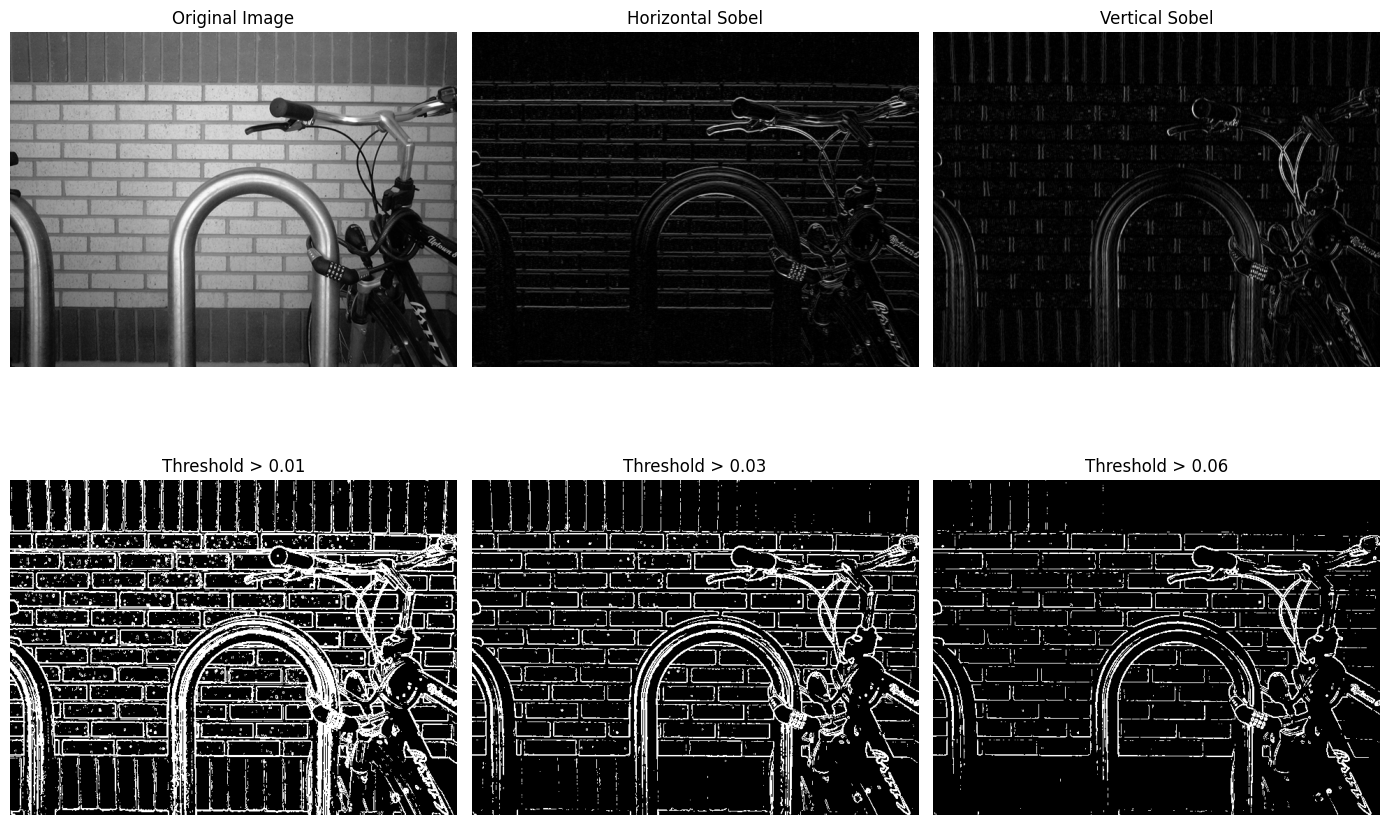

In [5]:
#Ex8_3: Edge Detection with Sobel Operators
# Create Sobel operators
ph = np.array([[-1, -2, -1],
               [ 0,  0,  0],
               [ 1,  2,  1]], dtype=np.float64)
pv = np.array([[-1,  0,  1],
               [-2,  0,  2],
               [-1,  0,  1]], dtype=np.float64)

# Apply Sobel in horizontal direction
filtered_Img1 = cv2.filter2D(Img, -1, ph, borderType=cv2.BORDER_REPLICATE)
filtered_Img1 = np.abs(filtered_Img1)
filtered_Img1 = filtered_Img1 / np.max(filtered_Img1) #normalize the filtered_Img1

# Apply Sobel in vertical direction
filtered_Img2 = cv2.filter2D(Img, -1, pv, borderType=cv2.BORDER_REPLICATE)
filtered_Img2 = np.abs(filtered_Img2)
filtered_Img2 = filtered_Img2 / np.max(filtered_Img2) #normalize the filtered_Img2

# Combine two operators in both directions
filtered_Img3 = filtered_Img1 ** 2 + filtered_Img2 ** 2
log_filtered_Img3 = np.log(filtered_Img3 + 1)
log_filtered_Img3 = log_filtered_Img3 / np.max(log_filtered_Img3) #normalize the filtered_Img3

# Get three different thresholds
bw_edge1 = log_filtered_Img3 > 0.01
bw_edge2 = log_filtered_Img3 > 0.03
bw_edge3 = log_filtered_Img3 > 0.06

# Display results
plt.figure(figsize=(14,10))

plt.subplot(2, 3, 1), plt.imshow(Img.astype(np.uint8), cmap='gray'), plt.title('Original Image', fontsize=FS), plt.axis('off')
plt.subplot(2, 3, 2), plt.imshow(filtered_Img1, cmap='gray'), plt.title('Horizontal Sobel', fontsize=FS), plt.axis('off')
plt.subplot(2, 3, 3), plt.imshow(filtered_Img2, cmap='gray'), plt.title('Vertical Sobel', fontsize=FS), plt.axis('off')
plt.subplot(2, 3, 4), plt.imshow(bw_edge1, cmap='gray'), plt.title('Threshold > 0.01', fontsize=FS), plt.axis('off')
plt.subplot(2, 3, 5), plt.imshow(bw_edge2, cmap='gray'), plt.title('Threshold > 0.03', fontsize=FS), plt.axis('off')
plt.subplot(2, 3, 6), plt.imshow(bw_edge3, cmap='gray'), plt.title('Threshold > 0.06', fontsize=FS), plt.axis('off')

plt.tight_layout()
plt.savefig(PATH + 'Ex8_3.jpg', dpi=400)
plt.show()

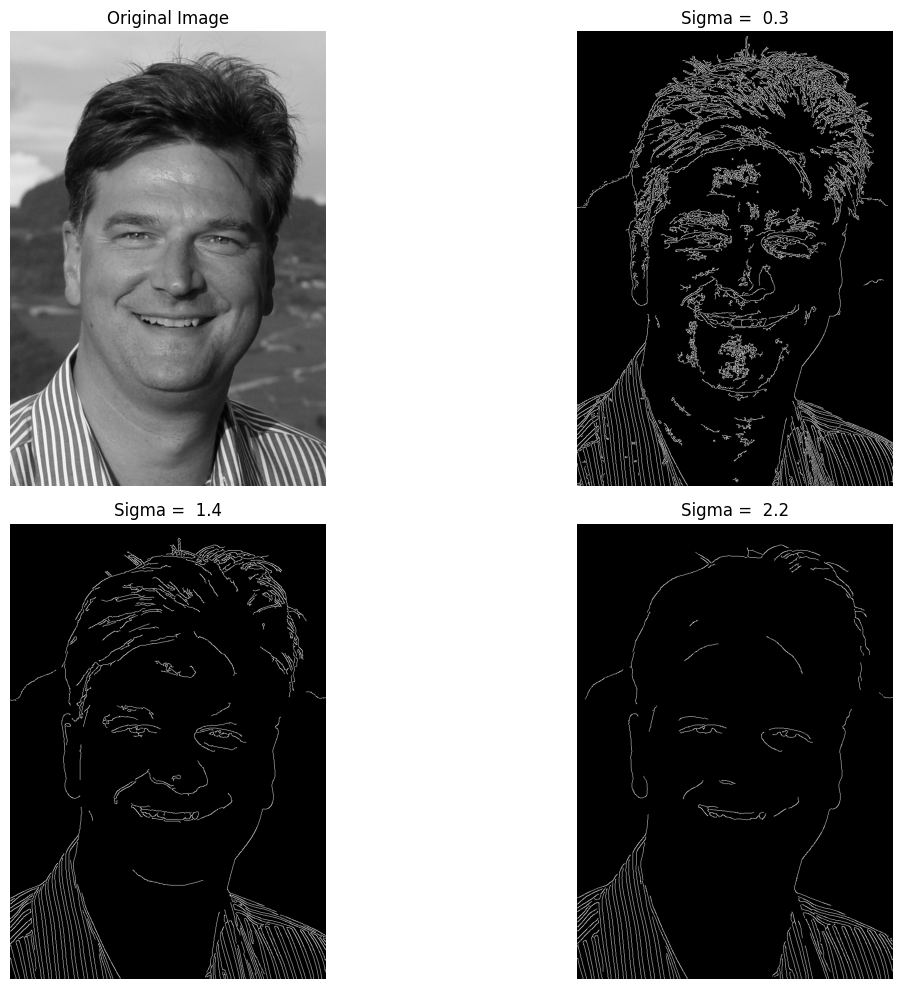

In [6]:
#Ex8_4: Canny Edge Detector
Img = cv2.imread(PATH + 'man_face.png', cv2.IMREAD_GRAYSCALE)

# Convert from integer to double format
Img = Img.astype(np.float64)

# Create a matrix of different sigmaValues
sigmaValues = [0.3, 1.4, 2.2]
thresholdValue = 0.5

# Calculate edge detection with different sigma values and display results
plt.figure(figsize=(14,10))
plt.subplot(2, 2, 1), plt.imshow(Img.astype(np.uint8), cmap='gray'), plt.title('Original Image', fontsize=FS), plt.axis('off')

# Scan all sigma values
for i, sigma in enumerate(sigmaValues):
  # Calculate the kernel size (must be an odd value)
  kernel = int(5 * sigma + 1)
  kernel = kernel + 1 if kernel % 2 == 0 else kernel

  # Smooth the input image with Gaussian LPF
  smoothed_Img = cv2.GaussianBlur(Img, (kernel, kernel), sigma)

  # Define two threshold values (T_low, T_high)
  T_low = int(0.15 * thresholdValue * 255)
  T_high = int(0.8 * thresholdValue * 255)

  # Apply Canny edge detector
  edges = cv2.Canny(smoothed_Img.astype(np.uint8), T_low, T_high)

  # Display result
  plt.subplot(2, 2, i+2), plt.imshow(edges, cmap='gray')
  plt.title(f'Sigma = {sigma: .1f}', fontsize=FS), plt.axis('off')

plt.tight_layout()
plt.savefig(PATH + 'Ex8_4.jpg', dpi=400)
plt.show()

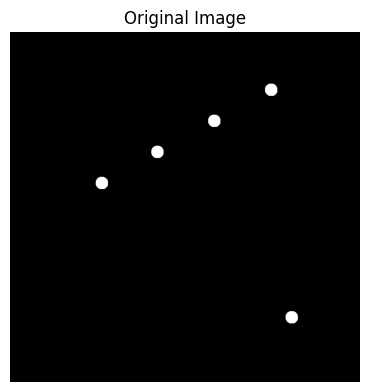

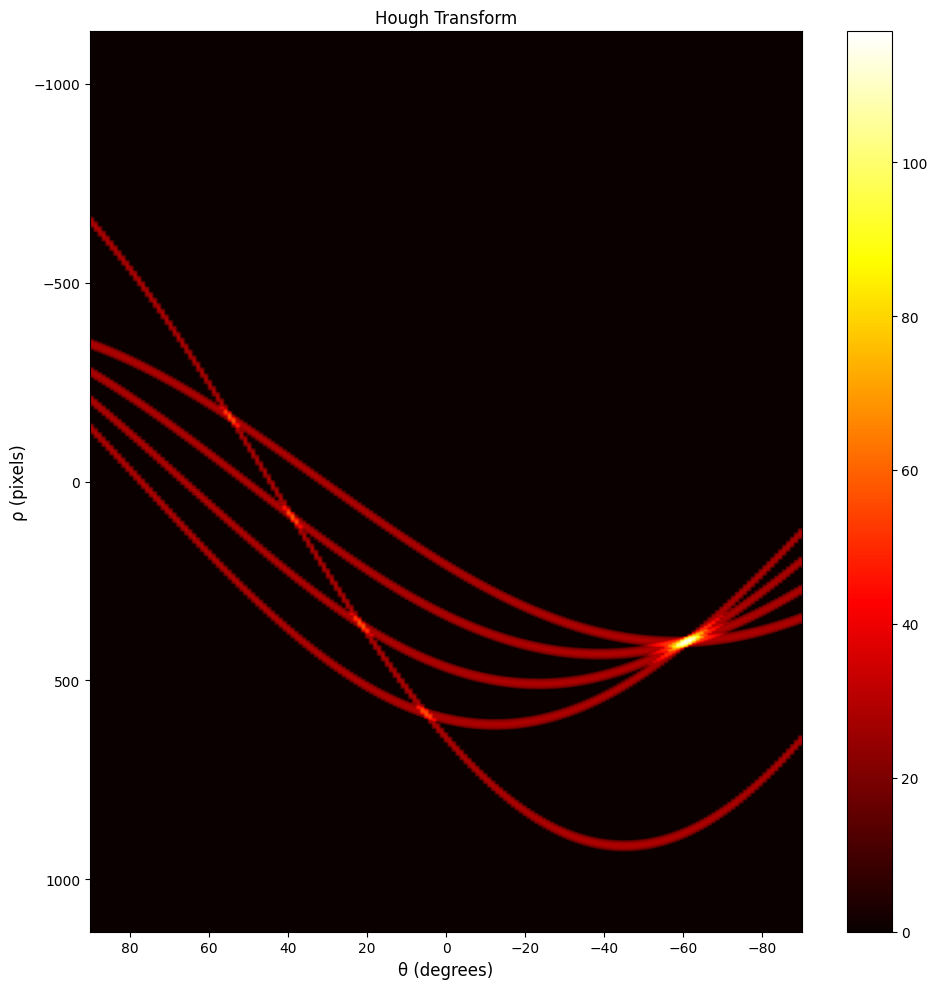

In [7]:
#Ex8_5: Hough Transform

from skimage.transform import hough_line, hough_line_peaks
from skimage.feature import canny

# Load image
Img = cv2.imread(PATH + 'dots.png', cv2.IMREAD_GRAYSCALE)

# Convert from integer to double format
Img = Img.astype(np.float64)


plt.figure(figsize=(10,10))
plt.subplot(2,2,1), plt.imshow(Img, cmap='gray'), plt.title('Original Image', fontsize=FS)
plt.axis('off')
plt.show()


# Calculate and display Hough transform
angles = np.linspace(-np.pi/2, np.pi/2, 181, endpoint=True) #draw a line every single degree
h, theta, d = hough_line(Img, theta=angles)

plt.figure(figsize=(10,10))
plt.imshow(h, extent=(np.rad2deg(theta[-1]), np.rad2deg(theta[0]), d[-1], d[0]), cmap='hot', aspect='auto')
plt.title('Hough Transform', fontsize=FS)
plt.xlabel('θ (degrees)', fontsize=FS)
plt.ylabel('ρ (pixels)', fontsize=FS)
plt.colorbar()
plt.tight_layout()
plt.show()

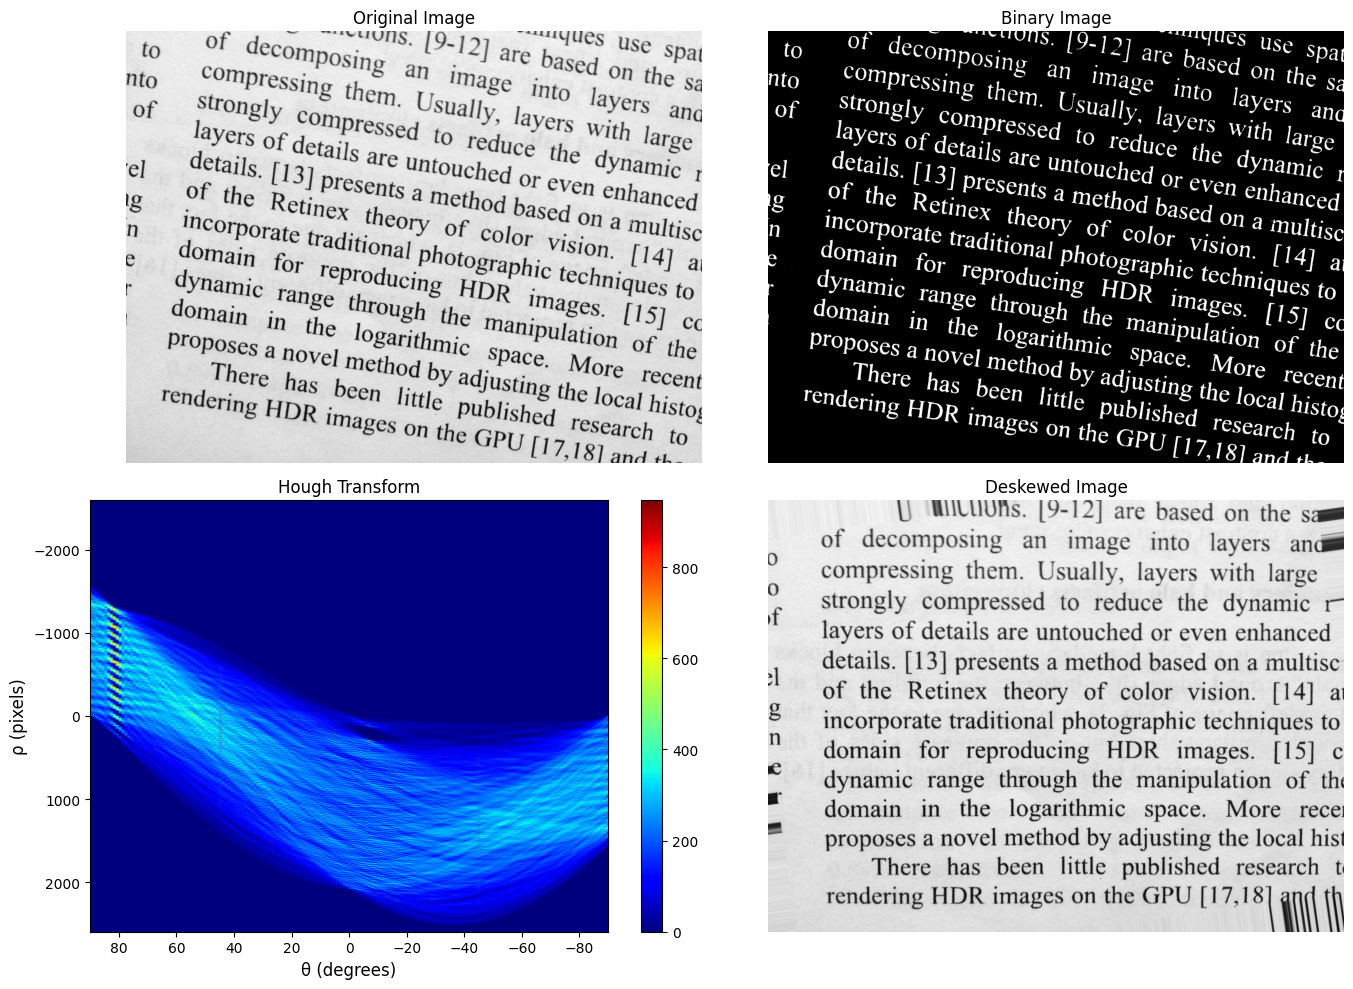

In [8]:
#Ex8_6: Hough transform application - Text Rotation

from skimage.transform import hough_line, hough_line_peaks, rotate
from skimage.feature import canny

Img = cv2.imread(PATH + 'paper.jpg', cv2.IMREAD_GRAYSCALE)

# Convert image from GRAYSCALE to BINARY using Otsu method
thres_val, Img_bw = cv2.threshold(Img, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

# Display results
plt.figure(figsize=(14,10))

plt.subplot(2,2,1), plt.imshow(Img, cmap='gray'), plt.title('Original Image', fontsize=FS)
plt.axis('off')
plt.subplot(2,2,2), plt.imshow(Img_bw, cmap='gray'), plt.title('Binary Image', fontsize=FS)
plt.axis('off')

# Calculate Hough Transform
angles = np.linspace(-np.pi/2, np.pi/2, 181, endpoint=True) #draw a line every single degree
h, theta, rho = hough_line(Img_bw, theta=angles)

#find biggest peak lines
peakNum = 20
accums, peak_angles, peak_rhos = hough_line_peaks(h, theta, rho, num_peaks=peakNum, threshold=0.2*np.max(h))

#display Hough transform
plt.subplot(2,2,3), plt.imshow(h, extent=(np.rad2deg(theta[-1]), np.rad2deg(theta[0]), rho[-1], rho[0]), cmap='jet', aspect='auto')
plt.title('Hough Transform', fontsize=FS)
plt.xlabel('θ (degrees)', fontsize=FS)
plt.ylabel('ρ (pixels)', fontsize=FS)
plt.colorbar()
plt.tight_layout()


# Rotate the original image with the median of peak lines
rotate_angle = np.median(np.rad2deg(peak_angles))
deskewed_Img = rotate(Img, (90 + rotate_angle), resize=False, mode='edge')

plt.subplot(2,2,4), plt.imshow(deskewed_Img, cmap='gray'), plt.title('Deskewed Image', fontsize=FS)
plt.axis('off')
plt.show()


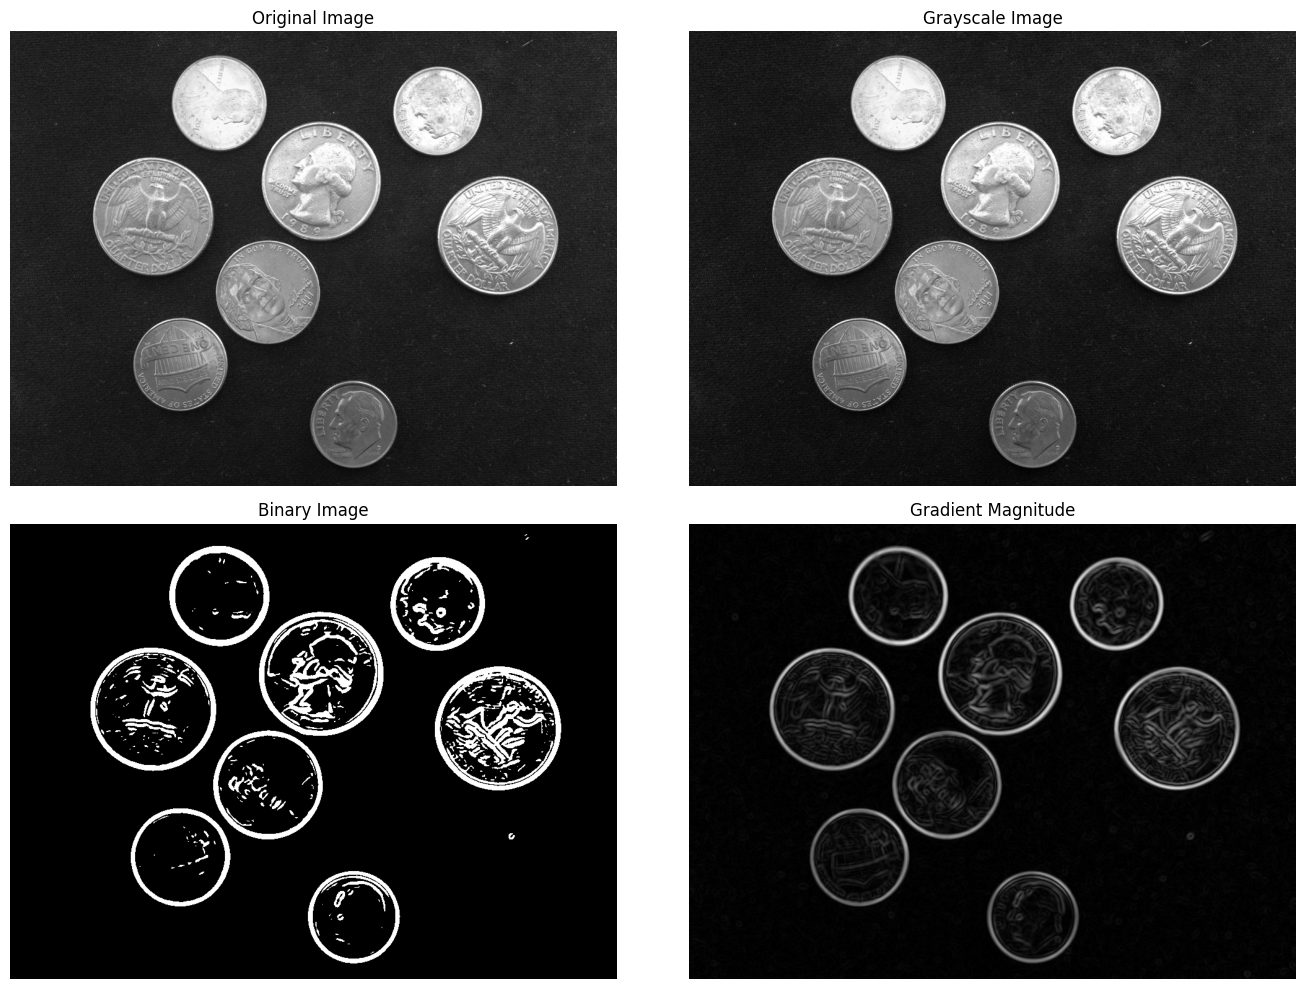

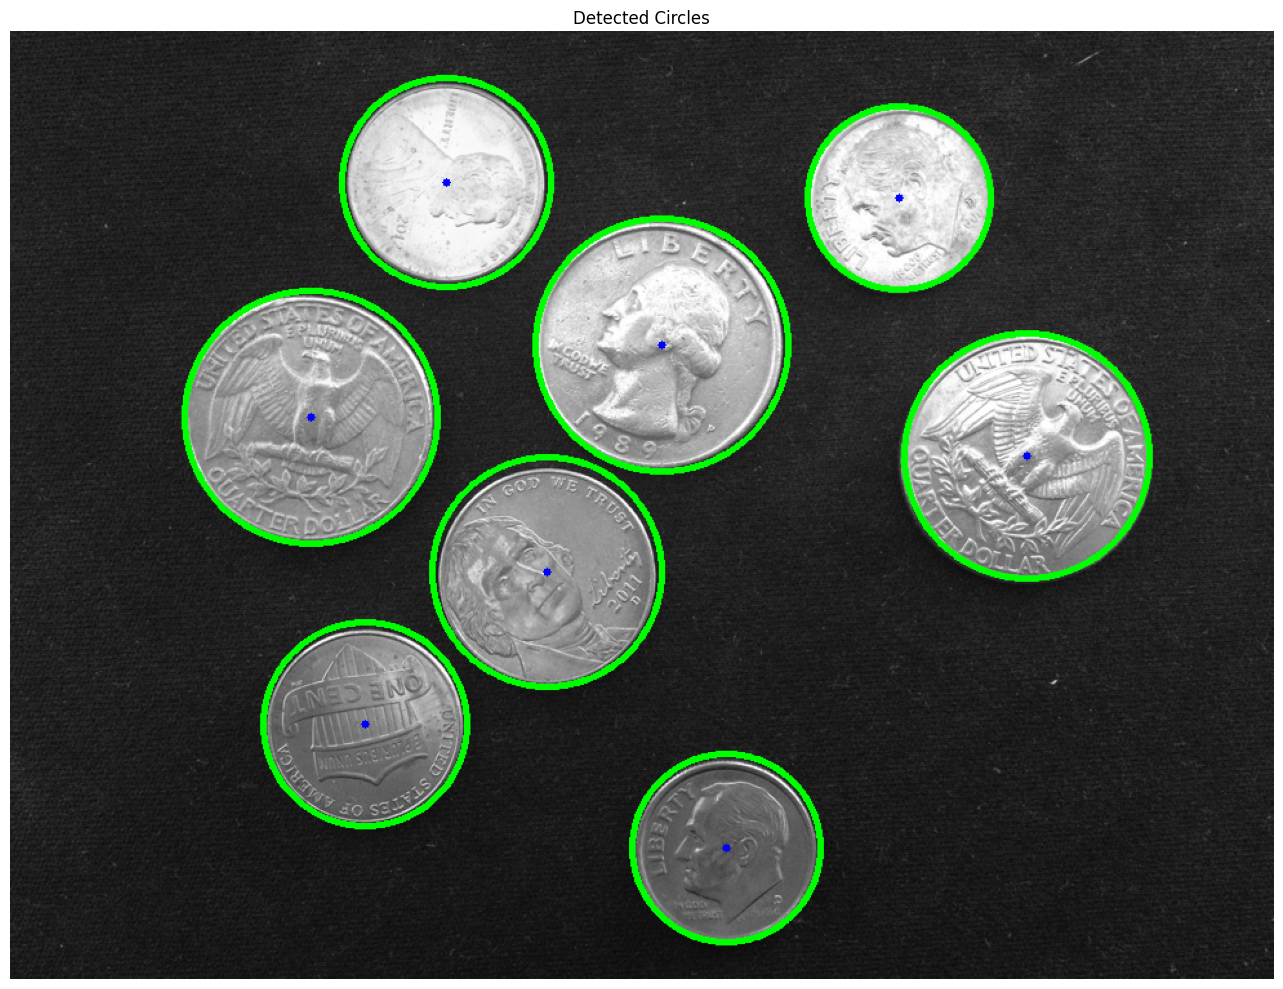

In [9]:
#Ex8_7: Hough Transform Application - Coin Edge Detection

# Load image
Img = cv2.imread(PATH + 'coins.png', cv2.IMREAD_COLOR_RGB)

# Convert from RGB to GRAYSCALE
Img_gray = cv2.cvtColor(Img, cv2.COLOR_RGB2GRAY)

# Smooth the image to reduce noise
smoothed_Img = cv2.GaussianBlur(Img_gray, (9,9), 3)

# Option 1: Using Prewitt operators
# Convert from integer to double format
smoothed_Img = smoothed_Img.astype(np.float64)

# Apply Prewitt filters to the image
Gx = cv2.filter2D(smoothed_Img, -1, ph, borderType=cv2.BORDER_REPLICATE)
Gy = cv2.filter2D(smoothed_Img, -1, pv, borderType=cv2.BORDER_REPLICATE)

# Calculate the gradient magnitude from Gx and Gy
mag = cv2.magnitude(Gx, Gy)
# Normalize the magnitude
mag_norm = cv2.normalize(mag, None, 0, 255, cv2.NORM_MINMAX, cv2.CV_8U).astype(np.uint8)

# Apply thresholding to detect edges
T = 0.15 * mag.max()
Img_bw = (mag >= T).astype(np.uint8) * 255

# Display results
plt.figure(figsize=(14,10))

plt.subplot(2, 2, 1), plt.imshow(Img), plt.title('Original Image', fontsize=FS), plt.axis('off')
plt.subplot(2, 2, 2), plt.imshow(Img_gray, cmap='gray'), plt.title('Grayscale Image', fontsize=FS), plt.axis('off')
plt.subplot(2, 2, 3), plt.imshow(Img_bw, cmap='gray'), plt.title('Binary Image', fontsize=FS), plt.axis('off')
plt.subplot(2, 2, 4), plt.imshow(mag_norm, cmap='gray'), plt.title('Gradient Magnitude', fontsize=FS), plt.axis('off')

plt.tight_layout()
plt.savefig(PATH + 'Ex8_7a.jpg', dpi=400)
plt.show()

#Option 2: Using Hough transform
#equalize the grayscale image
Img_eq = cv2.equalizeHist(smoothed_Img.astype(np.uint8))

#define Hough circle parameters
circles = cv2.HoughCircles(
    Img_eq,
    method=cv2.HOUGH_GRADIENT,
    dp=1.2,
    minDist=130,
    param1=120, #sensitivity 1
    param2=50, #sensitivity 2
    minRadius=70,
    maxRadius=120
)

#filter to find most suitable circles
if circles is not None:
  circles = np.uint16(np.around(circles[0]))
  for (x, y, r) in circles:
    #draw circles
    cv2.circle(Img, (x, y), r, (0, 255, 0), 3)
    #draw center points
    cv2.circle(Img, (x, y), 3, (0, 0, 255), -1)

#display results
plt.figure(figsize=(14,10))
plt.imshow(Img), plt.title('Detected Circles', fontsize=FS), plt.axis('off')

plt.tight_layout()
plt.savefig(PATH + 'Ex8_7b.jpg', dpi=400)
plt.show()

